# LAGO analysis of the SIPRI Arms Transfer Register

This notebook implements the official `dcd-lago` workflow for a real, directed, weighted temporal network:

1. upload and validate the SIPRI register;
2. map country names and years to normalized integer identifiers;
3. construct a directed and weighted `LinkStream`;
4. detect dynamic communities with `lago_modules`;
5. evaluate the partition with matching L-Modularity parameters;
6. inspect modules, country trajectories, supplier dominance and temporal stability;
7. optionally run parameter sensitivity, repeated restarts and a refined final model;
8. export a results bundle for interpretation and reporting.

### Primary network definition

The recommended primary analysis is an **instantaneous order-event network**:

- node: country or historical state;
- directed edge: supplier → recipient;
- time: year of order;
- weight: SIPRI TIV for the total order.

This measures the formation of procurement relationships. It does **not** measure the exact annual flow of delivered weapons.

The optional `deliveries-approx` mode divides delivered TIV equally across all listed delivery years. That is explicitly an analytical approximation, not an annual allocation reported by SIPRI.

Reference: Brabant, Bonifati & Cazabet (2026), *Generalized L-Modularity for Community Detection Beyond Simple Temporal Networks*, arXiv:2605.24450v1.

## 1. Installing packages

In [ ]:
%pip install -q "dcd-lago==1.1.0" pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.0/97.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
import json
import math
import re
import shutil
import time
import warnings
from collections import defaultdict
from functools import reduce
from importlib.metadata import version
from itertools import combinations
from math import gcd
from pathlib import Path
from statistics import mean, pstdev

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import adjusted_rand_score

from lago import LinkStream, lago_modules, longitudinal_modularity
from lago.viz import LongitudinalModulesPlot

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)

print("dcd-lago version:", version("dcd-lago"))

dcd-lago version: 1.1.0


## 2. Uploading the SIPRI CSV



In [ ]:
try:
    from google.colab import files as colab_files
except ImportError:
    colab_files = None

if colab_files is not None:
    uploaded = colab_files.upload()
    csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
    if len(csv_files) != 1:
        raise ValueError("Upload exactly one SIPRI CSV file.")
    DATA_PATH = Path(csv_files[0])
else:
    # Change this path when running outside Google Colab.
    DATA_PATH = Path("trade-register.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

print(f"Data file selected: {DATA_PATH}")

Saving trade-register.csv to trade-register.csv
Data file selected: trade-register.csv


## 3. Declaring the modelling decisions

- **`NETWORK_MODE`** determines whether the network represents orders or approximate deliveries.
- **`VARIANT`** determines whether direction and TIV magnitude are retained.
- **`LEX`** selects the longitudinal expectation: `MM` is flexible; `JM` favours longer-lasting membership.
- **γ (`GAMMA`)** controls community resolution. Higher values generally produce smaller communities.
- **ω (`OMEGA`)** penalizes community switching. Higher values produce smoother, more persistent lineages.
- **Refinement** improves the optimizer's solution but is expensive.
- **Restarts** assess optimizer sensitivity.

In [ ]:
# ----- Substantive network definition -----
NETWORK_MODE = "orders"              # "orders" or "deliveries-approx"
START_YEAR, END_YEAR = 1950, 2024
VARIANT = "directed-weighted"         # directed/undirected × weighted/unweighted

# ----- L-Modularity specification -----
LEX = "MM"                            # "MM" (flexible) or "JM" (persistent)
GAMMA = 1.0                           # topological resolution
OMEGA = 2.0                           # temporal switching penalty

# ----- Fast baseline settings -----
RESTARTS = 1
REFINEMENT = None
REFINEMENT_IN = False
FAST_EXPLORATION = True
STOPPING_CRITERION = 1e-6
VERBOSE = 1
SEED = 20260901

# ----- Data decisions -----
EXCLUDE_NON_STATE_ACTORS = True       # SIPRI marks non-state actors with "*"
HARMONIZE_USSR = True                 # map "Russia" to "Soviet Union" before 1992
ZERO_TIV = 0.25                       # midpoint for SIPRI values rounded to 0 (<0.5m)

# ----- Inspection choices -----
CHECK_YEARS = [1964, 1984, 1999, 2024]
COUNTRIES_TO_TRACK = [
    "United States", "Soviet Union", "Russia", "China",
    "India", "Germany", "France", "United Kingdom"
]

OUTPUT_DIR = Path("lago_sipri_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_VARIANTS = {
    "directed-weighted", "directed-unweighted",
    "undirected-weighted", "undirected-unweighted"
}
assert NETWORK_MODE in {"orders", "deliveries-approx"}
assert VARIANT in VALID_VARIANTS
assert LEX in {"MM", "JM"}
assert START_YEAR <= END_YEAR
assert 0 < ZERO_TIV < 0.5
assert RESTARTS >= 1

## 4. Cleaning the register

The SIPRI export contains metadata lines above the column header. The code detects the header instead of assuming that it will always occur on the same row.

Cleaning decisions:

- remove missing suppliers or recipients;
- strip whitespace;
- optionally remove non-state actors marked with `*`;
- remove entities containing “unknown”;
- remove self-loops;
- retain historical country names, except for the optional pre-1992 Russia/Soviet Union harmonization declared above.

In [ ]:
def find_header_row(path: Path) -> int:

    with path.open("r", encoding="latin-1") as handle:
        for row_number, line in enumerate(handle):
            if all(term in line for term in ["Recipient", "Supplier", "Year of order"]):
                return row_number
    raise ValueError("Could not locate the SIPRI header row.")


header_row = find_header_row(DATA_PATH)
raw = pd.read_csv(
    DATA_PATH,
    skiprows=header_row,
    encoding="latin-1",
    low_memory=False
)
raw.columns = raw.columns.str.strip()

required_columns = {
    "Recipient", "Supplier", "Year of order", "Year(s) of delivery",
    "SIPRI TIV for total order", "SIPRI TIV of delivered weapons"
}
missing_columns = required_columns - set(raw.columns)
if missing_columns:
    raise ValueError(f"Missing expected SIPRI columns: {sorted(missing_columns)}")

data = raw.dropna(subset=["Recipient", "Supplier"]).copy()
for column in ["Recipient", "Supplier"]:
    data[column] = data[column].astype(str).str.strip()
    if EXCLUDE_NON_STATE_ACTORS:
        data = data[~data[column].str.endswith("*")]
    data = data[~data[column].str.contains("unknown", case=False, na=False)]

data = data[data["Recipient"] != data["Supplier"]].copy()

cleaning_summary = pd.DataFrame({
    "measure": ["header_row", "raw_transactions", "retained_transactions"],
    "value": [header_row, len(raw), len(data)]
})
display(cleaning_summary)
display(data[[
    "Supplier", "Recipient", "Year of order", "Year(s) of delivery",
    "SIPRI TIV for total order", "SIPRI TIV of delivered weapons"
]].head())

,measure,value
0,header_row,11
1,raw_transactions,29916
2,retained_transactions,29304


,Supplier,Recipient,Year of order,Year(s) of delivery,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Russia,Afghanistan,2010,2011,17.4,17.4
1,Russia,Afghanistan,2004,2005,11.6,11.6
2,Soviet Union,Afghanistan,1960,1960; 1961,4.0,4.0
3,Soviet Union,Afghanistan,1978,1979; 1980; 1981; 1982; 1983; 1984; 1985; 1986; 1987; 1988; 1990; 1991,250.0,250.0
4,Soviet Union,Afghanistan,1987,1987; 1988; 1989; 1990,171.2,171.2


## 5. Construct annual supplier-recipient edges

### Orders (primary)

Each transaction is placed at its order year and weighted by total-order TIV. Multiple transactions involving the same supplier, recipient and year are summed.

### Approximate deliveries (sensitivity only)

The delivered TIV of a transaction is divided equally across every listed delivery year. This assumes a uniform annual allocation and must not be described as observed annual SIPRI flows.

SIPRI values displayed as zero represent positive TIV below the reporting precision. The configured midpoint replacement is applied consistently and recorded in the manifest.

In [ ]:
def parse_delivery_years(value) -> list[int]:
    if pd.isna(value):
        return []
    return sorted({int(year) for year in re.findall(r"\b(?:19|20)\d{2}\b", str(value))})


def positive_tiv(value) -> float | None:
    number = pd.to_numeric(value, errors="coerce")
    if pd.isna(number) or not math.isfinite(float(number)) or float(number) < 0:
        return None
    return ZERO_TIV if float(number) == 0 else float(number)


def harmonize_country_names(supplier: str, recipient: str, year: int):
    if HARMONIZE_USSR and year < 1992:
        supplier = "Soviet Union" if supplier == "Russia" else supplier
        recipient = "Soviet Union" if recipient == "Russia" else recipient
    return supplier, recipient


annual_weights = defaultdict(float)

for _, row in data.iterrows():
    if NETWORK_MODE == "orders":
        order_year = pd.to_numeric(row["Year of order"], errors="coerce")
        if pd.isna(order_year):
            continue
        years = [int(order_year)]
        annual_weight = positive_tiv(row["SIPRI TIV for total order"])
    else:
        years = parse_delivery_years(row["Year(s) of delivery"])
        delivered_tiv = positive_tiv(row["SIPRI TIV of delivered weapons"])
        annual_weight = delivered_tiv / len(years) if delivered_tiv is not None and years else None

    if annual_weight is None:
        continue

    for year in years:
        if START_YEAR <= year <= END_YEAR:
            supplier, recipient = harmonize_country_names(
                row["Supplier"], row["Recipient"], year
            )
            if supplier != recipient:
                annual_weights[(supplier, recipient, year)] += annual_weight

edges = pd.DataFrame(
    [(supplier, recipient, year, weight)
     for (supplier, recipient, year), weight in sorted(annual_weights.items())],
    columns=["supplier", "recipient", "year", "weight"]
)

if edges.empty:
    raise ValueError("No edges remain after preprocessing and period filtering.")

edges.to_csv(OUTPUT_DIR / "preprocessed_edges.csv", index=False)

edge_summary = pd.DataFrame({
    "measure": ["annual_dyad_edges", "countries", "first_year", "last_year", "total_weight"],
    "value": [
        len(edges),
        len(set(edges["supplier"]) | set(edges["recipient"])),
        int(edges["year"].min()),
        int(edges["year"].max()),
        float(edges["weight"].sum())
    ]
})
display(edge_summary)
display(edges.head())

,measure,value
0,annual_dyad_edges,15264.0
1,countries,195.0
2,first_year,1950.0
3,last_year,2024.0
4,total_weight,2251812.5


,supplier,recipient,year,weight
0,Albania,Burkina Faso,2011,1.20
1,Algeria,Angola,1980,6.00
2,Algeria,Nigeria,1967,5.76
3,Algeria,Western Sahara,1982,17.40
4,Algeria,Western Sahara,1983,7.20


## 6. Build the normalized LAGO LinkStream

LAGO uses integer node IDs and normalized integer timestamps. Country names are mapped bidirectionally, and the first observed year becomes time 0. Because the substantive temporal unit is one year, consecutive calendar years remain one LAGO time unit apart.

The primary specification is directed and weighted. Alternative variants are sensitivity tests:

- **directed-weighted:** preserves supplier/recipient roles and TIV;
- **directed-unweighted:** preserves roles but treats every annual dyad equally;
- **undirected-weighted:** preserves TIV but removes supplier/recipient roles;
- **undirected-unweighted:** retains only annual dyad presence.

In [ ]:
def transform_edges(frame: pd.DataFrame, variant: str) -> pd.DataFrame:
    directed = variant.startswith("directed")
    weighted = variant.endswith("-weighted")
    totals = defaultdict(float)

    for row in frame.itertuples(index=False):
        source, target = row.supplier, row.recipient
        if not directed and target < source:
            source, target = target, source

        key = (source, target, int(row.year))
        if weighted:
            totals[key] += float(row.weight)
        else:
            totals[key] = 1.0

    return pd.DataFrame(
        [(source, target, year, weight)
         for (source, target, year), weight in sorted(totals.items())],
        columns=["supplier", "recipient", "year", "weight"]
    )


def make_linkstream(frame: pd.DataFrame, variant: str):
    countries = sorted(set(frame["supplier"]) | set(frame["recipient"]))
    node_to_id = {country: node_id for node_id, country in enumerate(countries)}
    id_to_node = {node_id: country for country, node_id in node_to_id.items()}

    first_year = int(frame["year"].min())
    normalized_times = sorted({int(year) - first_year for year in frame["year"]})
    time_differences = [
        later - earlier for earlier, later in zip(normalized_times, normalized_times[1:])
        if later > earlier
    ]
    time_gcd = reduce(gcd, time_differences) if time_differences else 1
    if time_gcd != 1:
        warnings.warn(
            f"Observed time-step GCD is {time_gcd}, not 1. Review time normalization before interpreting omega."
        )

    links = [
        (
            node_to_id[row.supplier],
            node_to_id[row.recipient],
            int(row.year) - first_year,
            float(row.weight)
        )
        for row in frame.itertuples(index=False)
    ]

    stream = LinkStream(directed=variant.startswith("directed"))
    stream.add_links(links)
    return stream, node_to_id, id_to_node, first_year, time_gcd


model_edges = transform_edges(edges, VARIANT)
stream, node_to_id, id_to_node, first_year, time_gcd = make_linkstream(model_edges, VARIANT)

node_map = pd.DataFrame(
    [{"node_id": node_id, "country": country}
     for country, node_id in sorted(node_to_id.items(), key=lambda item: item[1])]
)
node_map.to_csv(OUTPUT_DIR / "node_map.csv", index=False)

linkstream_audit = pd.DataFrame({
    "measure": [
        "variant", "directed", "nodes", "temporal_edges", "total_weight",
        "normalized_min_time", "normalized_max_time", "time_step_gcd"
    ],
    "value": [
        VARIANT, VARIANT.startswith("directed"), stream.nb_nodes, stream.nb_edges,
        stream.weight, stream.min_time, stream.max_time, time_gcd
    ]
})
display(linkstream_audit)

,measure,value
0,variant,directed-weighted
1,directed,True
2,nodes,195
3,temporal_edges,15264
4,total_weight,2251812.5
5,normalized_min_time,0
6,normalized_max_time,74
7,time_step_gcd,1


## 7. Detect communities and evaluate L-Modularity

`lago_modules` is the optimizer; `longitudinal_modularity` is the objective function. The evaluation must use the same `LEX`, γ and ω as the optimization.

The optimizer is stochastic. Independent restarts may produce different partitions. For a fixed specification, the notebook retains the run with the highest L-Modularity and calculates mean pairwise Adjusted Rand Index (ARI) when at least two restarts are available.

- ARI = 1: identical partitions up to community-label renaming;
- ARI near 0: weak agreement;
- with one restart, ARI is correctly reported as missing rather than 1.

The verbose optimizer prints a large internal objective value. The normalized `metric.value` printed after completion is the L-Modularity value to report.

In [ ]:
def membership_labels(modules) -> dict[tuple[int, int], int]:
    # Return {(node_id, normalized_time): community_id}.
    result = {}
    start, end = modules.time_range
    for normalized_time in range(start, end + 1):
        snapshot = modules.get_nodes_modules_membership_at_time(normalized_time)
        for node_id, community_id in snapshot.items():
            result[(node_id, normalized_time)] = community_id
    return result


def mean_partition_ari(partitions: list[dict]) -> float | None:
    # Mean label-invariant agreement between independent LAGO runs.
    pairwise_scores = []
    for left, right in combinations(partitions, 2):
        common = sorted(set(left) & set(right))
        if len(common) < 2:
            continue
        pairwise_scores.append(
            adjusted_rand_score(
                [left[key] for key in common],
                [right[key] for key in common]
            )
        )
    return mean(pairwise_scores) if pairwise_scores else None


def run_lago_configuration(
    stream,
    *,
    lex: str,
    gamma: float,
    omega: float,
    restarts: int,
    refinement,
    refinement_in: bool,
    fast_exploration: bool,
    stopping_criterion: float,
    verbose: int,
    seed: int,
):
    candidates = []
    partitions = []
    run_rows = []

    for restart in range(restarts):
        run_seed = seed + restart
        print(f"Starting restart {restart + 1}/{restarts} (seed={run_seed})...")
        started = time.perf_counter()

        modules = lago_modules(
            stream,
            lex=lex,
            gamma=gamma,
            omega=omega,
            nb_iter=1,
            refinement=refinement,
            fast_exploration=fast_exploration,
            refinement_in=refinement_in if refinement is not None else False,
            stopping_criterion=stopping_criterion,
            verbose=verbose,
            seed=run_seed,
        )

        metric = longitudinal_modularity(
            stream,
            modules,
            lex=lex,
            gamma=gamma,
            omega=omega,
            ndigits=10,
        )

        elapsed_seconds = time.perf_counter() - started
        candidates.append((metric.value, modules, metric, restart, elapsed_seconds))
        partitions.append(membership_labels(modules))
        run_rows.append({
            "restart": restart + 1,
            "seed": run_seed,
            "l_modularity": metric.value,
            "topological_component": metric.modularity_without_penalty,
            "time_penalty": metric.time_penalty,
            "communities": modules.nb_modules,
            "runtime_seconds": elapsed_seconds,
        })
        print(
            f"Finished restart {restart + 1}/{restarts}: "
            f"L-Modularity={metric.value:.4f}, modules={modules.nb_modules}, "
            f"runtime={elapsed_seconds / 60:.1f} minutes"
        )

    candidates.sort(key=lambda item: item[0], reverse=True)
    best_score, best_modules, best_metric, best_restart, best_runtime = candidates[0]

    return {
        "best_score": best_score,
        "best_modules": best_modules,
        "best_metric": best_metric,
        "best_restart": best_restart + 1,
        "best_runtime_seconds": best_runtime,
        "scores": [row[0] for row in candidates],
        "stability_ari": mean_partition_ari(partitions),
        "run_table": pd.DataFrame(run_rows),
    }

In [ ]:
baseline = run_lago_configuration(
    stream,
    lex=LEX,
    gamma=GAMMA,
    omega=OMEGA,
    restarts=RESTARTS,
    refinement=REFINEMENT,
    refinement_in=REFINEMENT_IN,
    fast_exploration=FAST_EXPLORATION,
    stopping_criterion=STOPPING_CRITERION,
    verbose=VERBOSE,
    seed=SEED,
)

best_score = baseline["best_score"]
best_modules = baseline["best_modules"]
best_metric = baseline["best_metric"]
stability_ari = baseline["stability_ari"]

baseline["run_table"].to_csv(OUTPUT_DIR / "baseline_restarts.csv", index=False)
display(baseline["run_table"])

Starting restart 1/1 (seed=20260901)...
LAGO: 195 nodes, 15264 edges, lex=MM, refinement=None
Starting iteration 1/1
	Optimized level 0 :: Δ L-Modularity = 0.65204345
	Optimized level 1 :: Δ L-Modularity = 0.26011473
	Optimized level 2 :: Δ L-Modularity = 0.1095627
	Optimized level 3 :: Δ L-Modularity = 0.04575785
	Optimized level 4 :: Δ L-Modularity = 0.01757371
	Optimized level 5 :: Δ L-Modularity = 0.00247884
	Optimized level 6 :: Δ L-Modularity = 0.00123137
	Optimized level 7 :: Δ L-Modularity = 0.00093466
	Optimized level 8 :: Δ L-Modularity = 0.00020928
	Optimized level 9 :: Δ L-Modularity = 0.00015895
	Optimized level 10 :: Δ L-Modularity = 5.952e-05
	Optimized level 11 :: Δ L-Modularity = 4.507e-05
	Optimized level 12 :: Δ L-Modularity = 3.303e-05
	Optimized level 13 :: Δ L-Modularity = 2.322e-05
	Optimized level 14 :: Δ L-Modularity = 1.241e-05
	Optimized level 15 :: Δ L-Modularity = 4.85e-06
	Optimized level 16 :: Δ L-Modularity = 2.37e-06
	Optimized level 17 :: Δ L-Modularit

,restart,seed,l_modularity,topological_component,time_penalty,communities,runtime_seconds
0,1,20260901,0.338474,0.356556,-0.018082,22,48.797177


## 8. Baseline summary and reproducibility manifest

L-Modularity consists of a topological component plus a normally negative temporal switching penalty. The number of modules is the number of longitudinal time modules across the full period, not necessarily the number present simultaneously in any one year.

The manifest records the data and modelling decisions required to reproduce and interpret the result.

In [10]:
switch_count = sum(
    len(best_modules.get_node_switches(node_id))
    for node_id in node_to_id.values()
)

baseline_summary = pd.DataFrame([{
    "network_mode": NETWORK_MODE,
    "variant": VARIANT,
    "lex": LEX,
    "gamma": GAMMA,
    "omega": OMEGA,
    "refinement": "None" if REFINEMENT is None else REFINEMENT,
    "refinement_in": REFINEMENT_IN,
    "restarts": RESTARTS,
    "best_restart": baseline["best_restart"],
    "best_l_modularity": best_score,
    "run_score_mean": mean(baseline["scores"]),
    "run_score_sd": pstdev(baseline["scores"]),
    "partition_ari_mean": stability_ari,
    "topological_component": best_metric.modularity_without_penalty,
    "time_penalty": best_metric.time_penalty,
    "modules": best_modules.nb_modules,
    "country_switches": switch_count,
    "active_country_years": len(membership_labels(best_modules)),
    "nodes": stream.nb_nodes,
    "temporal_edges": stream.nb_edges,
    "total_weight": stream.weight,
    "best_runtime_minutes": baseline["best_runtime_seconds"] / 60,
}])

baseline_summary.to_csv(OUTPUT_DIR / "baseline_summary.csv", index=False)
display(baseline_summary.T.rename(columns={0: "value"}))

manifest = {
    "data_file": DATA_PATH.name,
    "network_mode": NETWORK_MODE,
    "network_definition": (
        "Order year weighted by total-order TIV"
        if NETWORK_MODE == "orders"
        else "Delivered TIV divided equally across listed delivery years (approximation)"
    ),
    "period": [START_YEAR, END_YEAR],
    "variant": VARIANT,
    "exclude_non_state_actors": EXCLUDE_NON_STATE_ACTORS,
    "harmonize_russia_to_soviet_union_before_1992": HARMONIZE_USSR,
    "zero_tiv_replacement": ZERO_TIV,
    "time_normalization": f"calendar year minus {first_year}; one unit = one year",
    "lex": LEX,
    "gamma": GAMMA,
    "omega": OMEGA,
    "restarts": RESTARTS,
    "refinement": REFINEMENT,
    "refinement_in": REFINEMENT_IN,
    "fast_exploration": FAST_EXPLORATION,
    "stopping_criterion": STOPPING_CRITERION,
    "seed": SEED,
    "software": {"dcd-lago": version("dcd-lago")},
    "interpretation_status": (
        "Preliminary unrefined result"
        if REFINEMENT is None
        else "Refined result"
    ),
}

with (OUTPUT_DIR / "run_manifest.json").open("w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

,value
network_mode,orders
variant,directed-weighted
lex,MM
gamma,1.0
omega,2.0
refinement,None
refinement_in,False
restarts,1
best_restart,1
best_l_modularity,0.338474


## 9. Inspect modules as longitudinal objects

The official workflow examines each module's nodes, duration, time range and cohesion. A module is a lineage through time: its full set of nodes need not be present simultaneously.

`cohesion` and duration are descriptive diagnostics.

In [11]:
module_rows = []
segment_rows = []

for module in best_modules.iter_modules():
    module_start, module_end = module.time_range
    member_names = sorted(id_to_node[node_id] for node_id in module.nodes)
    module_rows.append({
        "community": module.label,
        "number_of_nodes": module.size,
        "duration_time_steps": module.duration,
        "start_year": module_start + first_year,
        "end_year": module_end + first_year,
        "cohesion": module.cohesion,
        "members_over_full_lifetime": ", ".join(member_names),
    })

    for node_id, segments in module.get_node_segments().items():
        for segment in segments:
            segment_rows.append({
                "community": module.label,
                "country": id_to_node[node_id],
                "segment_start_year": segment.start + first_year,
                "segment_end_year": segment.end + first_year,
            })

module_diagnostics = pd.DataFrame(module_rows).sort_values(
    ["duration_time_steps", "number_of_nodes"], ascending=False
)
module_segments = pd.DataFrame(segment_rows)

module_diagnostics.to_csv(OUTPUT_DIR / "module_diagnostics.csv", index=False)
module_segments.to_csv(OUTPUT_DIR / "module_segments.csv", index=False)
best_modules.to_json(OUTPUT_DIR / "baseline_communities.json", use_segments=True)

display(module_diagnostics)

,community,number_of_nodes,duration_time_steps,start_year,end_year,cohesion,members_over_full_lifetime
21,21,107,75,1950,2024,0.496698,"Argentina, Australia, Austria, Bahamas, Bahrain, Bangladesh, Barbados, Belarus, Belgium, Belize, Bolivia, Bosnia-Herzegovina, Botswana, Brazil, Brunei, Bulg..."
1,1,72,75,1950,2024,0.345926,"Algeria, Angola, Armenia, Aruba, Azerbaijan, Bangladesh, Belarus, Belgium, Bhutan, Cambodia, Central African Republic, China, Cyprus, Czechia, Egypt, Equato..."
16,16,68,75,1950,2024,0.319020,"Afghanistan, Algeria, Angola, Australia, Austria, Benin, Brazil, Bulgaria, Burundi, Cabo Verde, Cameroon, Canada, China, Congo, Cote d'Ivoire, Cuba, Czechos..."
10,10,59,75,1950,2024,0.386441,"Argentina, Australia, Austria, Belgium, Biafra, Brazil, Burkina Faso, Canada, Chile, Colombia, Comoros, Denmark, Ecuador, El Salvador, Finland, France, Germ..."
9,9,26,75,1950,2024,0.305128,"Albania, Algeria, China, Czechoslovakia, East Germany (GDR), Egypt, Finland, France, Guinea, Hungary, India, Indonesia, Iraq, Mongolia, Morocco, North Korea..."
13,13,14,74,1950,2023,0.278958,"Australia, Bangladesh, China, Egypt, Gambia, Iran, Iraq, Myanmar, North Korea, Pakistan, Sierra Leone, Sudan, Switzerland, Thailand"
4,4,12,67,1958,2024,0.503731,"China, DR Congo, Djibouti, Egypt, France, Ghana, Madagascar, North Korea, Pakistan, Somalia, Spain, Togo"
17,17,1,39,1982,2020,1.000000,Argentina
0,0,11,23,1950,1972,0.166008,"Canada, Cuba, Czechoslovakia, Germany, India, Israel, Poland, Soviet Union, Turkiye, United Kingdom, United States"
7,7,1,15,1955,1969,1.000000,Libya


## 10. Export country-year memberships and inspect benchmark years

Country-year membership tables answer a different question from module diagnostics: they show which countries are assigned together at one particular time.

The four benchmark years below correspond to the endpoints of the earlier five-year exploratory windows. Community numbers are arbitrary labels; interpret membership composition, not the numeric label itself.

In [12]:
membership_rows = [
    {
        "country": id_to_node[node_id],
        "year": normalized_time + first_year,
        "community": community_id,
    }
    for (node_id, normalized_time), community_id
    in sorted(membership_labels(best_modules).items())
]

memberships = pd.DataFrame(membership_rows)
memberships.to_csv(OUTPUT_DIR / "country_year_memberships.csv", index=False)

benchmark_tables = []
for year in CHECK_YEARS:
    current = memberships[memberships["year"] == year]
    if current.empty:
        print(f"No active memberships found for {year}.")
        continue

    table = (
        current.groupby("community")["country"]
        .agg(
            number_of_countries="size",
            countries=lambda values: ", ".join(sorted(values)),
        )
        .reset_index()
        .sort_values("number_of_countries", ascending=False)
    )
    table.insert(0, "year", year)
    benchmark_tables.append(table)
    print(f"\nCommunities active in {year}")
    display(table)

benchmark_communities = (
    pd.concat(benchmark_tables, ignore_index=True)
    if benchmark_tables else pd.DataFrame()
)
benchmark_communities.to_csv(OUTPUT_DIR / "benchmark_year_communities.csv", index=False)


Communities active in 1964


,year,community,number_of_countries,countries
5,1964,10,44,"Argentina, Australia, Austria, Belgium, Brazil, Burkina Faso, Chile, Colombia, Denmark, Ecuador, El Salvador, France, Germany, Greece, Haiti, Indonesia, Ira..."
12,1964,21,20,"Bolivia, Brunei, Chad, Costa Rica, Cyprus, Dominican Republic, Honduras, Iceland, Ireland, Jamaica, Kenya, Lebanon, Luxembourg, Mauritania, Niger, Panama, P..."
4,1964,9,16,"Albania, Algeria, China, East Germany (GDR), Egypt, Finland, Guinea, Hungary, Iraq, Mongolia, Morocco, North Korea, Romania, Syria, Viet Nam, Yugoslavia"
9,1964,16,13,"Afghanistan, Benin, Bulgaria, Cameroon, Congo, Cote d'Ivoire, Ethiopia, Gabon, Guatemala, Malawi, Nicaragua, North Yemen, Senegal"
1,1964,1,10,"Cambodia, Central African Republic, Laos, Mali, Nepal, Rwanda, Sri Lanka, Uganda, Ukraine, Zimbabwe"
0,1964,0,7,"Canada, Cuba, Czechoslovakia, India, Poland, Soviet Union, Turkiye"
2,1964,4,5,"DR Congo, Ghana, Madagascar, Somalia, Togo"
7,1964,13,3,"Myanmar, Sudan, Thailand"
3,1964,7,1,Libya
8,1964,14,1,Pakistan



Communities active in 1984


,year,community,number_of_countries,countries
7,1984,21,62,"Australia, Bahamas, Bahrain, Barbados, Belgium, Belize, Bolivia, Botswana, Brazil, Brunei, Canada, Chad, Costa Rica, Cyprus, Denmark, Dominican Republic, Ec..."
5,1984,16,44,"Afghanistan, Algeria, Angola, Austria, Benin, Bulgaria, Burundi, Cabo Verde, Cameroon, Congo, Cote d'Ivoire, Cuba, Czechoslovakia, East Germany (GDR), Ethio..."
0,1984,1,15,"Bhutan, Cambodia, Central African Republic, Equatorial Guinea, Hungary, Laos, Mali, Morocco, Nepal, Rwanda, Seychelles, Sri Lanka, Uganda, Ukraine, Zimbabwe"
3,1984,10,13,"Burkina Faso, Chile, Colombia, Comoros, El Salvador, Liberia, Oman, Papua New Guinea, Philippines, South Africa, Tanzania, Zambia, eSwatini"
4,1984,13,9,"Bangladesh, China, Egypt, Gambia, Myanmar, Pakistan, Sierra Leone, Sudan, Thailand"
1,1984,4,6,"DR Congo, Djibouti, Ghana, Madagascar, Somalia, Togo"
2,1984,9,3,"Albania, Guinea, Mongolia"
6,1984,17,1,Argentina



Communities active in 1999


,year,community,number_of_countries,countries
7,1999,21,85,"Australia, Austria, Bahamas, Bahrain, Bangladesh, Barbados, Belgium, Belize, Bolivia, Bosnia-Herzegovina, Botswana, Brazil, Brunei, Bulgaria, Canada, Chad, ..."
0,1999,1,43,"Algeria, Angola, Armenia, Azerbaijan, Belarus, Bhutan, Cambodia, Central African Republic, China, Cyprus, Czechia, Equatorial Guinea, Eritrea, Georgia, Indi..."
5,1999,16,19,"Afghanistan, Benin, Burundi, Cabo Verde, Cameroon, Congo, Cote d'Ivoire, Cuba, Ethiopia, Gabon, Guatemala, Guyana, Lesotho, Malawi, Mauritius, Mozambique, N..."
3,1999,10,9,"Burkina Faso, Comoros, El Salvador, Liberia, Papua New Guinea, Philippines, Tanzania, Zambia, eSwatini"
1,1999,4,6,"DR Congo, Djibouti, Ghana, Madagascar, Somalia, Togo"
2,1999,9,3,"Albania, Guinea, Mongolia"
4,1999,13,3,"Gambia, Sierra Leone, Sudan"
6,1999,17,1,Argentina



Communities active in 2024


,year,community,number_of_countries,countries
5,2024,21,74,"Argentina, Australia, Austria, Belgium, Bosnia-Herzegovina, Botswana, Brazil, Brunei, Bulgaria, Canada, Chad, Chile, Colombia, Croatia, Czechia, Denmark, Do..."
0,2024,1,20,"Algeria, Armenia, Azerbaijan, Bangladesh, Belarus, China, India, Iran, Kazakhstan, Mali, Moldova, Namibia, North Korea, Pakistan, Russia, Tajikistan, Tanzan..."
4,2024,16,6,"Benin, Cote d'Ivoire, Ethiopia, Gabon, Guatemala, Guyana"
1,2024,4,5,"DR Congo, Djibouti, Ghana, Madagascar, Togo"
3,2024,10,3,"Burkina Faso, El Salvador, Liberia"
2,2024,9,1,Albania


## 11. Diagnose supplier-centred communities

The earlier results may reflect genuine blocs, but they may also reflect a hub-and-spoke structure in which one dominant exporter is connected to many otherwise unrelated customers.

For each community-year, this section calculates:

- internal TIV: supplier and recipient are in the same detected community;
- internal share of outgoing TIV: how much of community suppliers' outgoing TIV remains within the community;
- leading supplier share: how much internal TIV comes from the largest supplier.

A very high leading-supplier share supports a supplier-centred interpretation. It does not by itself prove or disprove geopolitical cohesion.

In [13]:
supplier_membership = memberships.rename(columns={
    "country": "supplier",
    "community": "supplier_community",
})
recipient_membership = memberships.rename(columns={
    "country": "recipient",
    "community": "recipient_community",
})

classified_edges = (
    edges
    .merge(
        supplier_membership[["supplier", "year", "supplier_community"]],
        on=["supplier", "year"], how="left"
    )
    .merge(
        recipient_membership[["recipient", "year", "recipient_community"]],
        on=["recipient", "year"], how="left"
    )
)

classified_edges["internal"] = (
    classified_edges["supplier_community"].notna()
    & (classified_edges["supplier_community"] == classified_edges["recipient_community"])
)

internal_edges = classified_edges[classified_edges["internal"]].copy()

internal_totals = (
    internal_edges.groupby(["year", "supplier_community"], as_index=False)["weight"]
    .sum().rename(columns={
        "supplier_community": "community",
        "weight": "internal_tiv",
    })
)

outgoing_totals = (
    classified_edges.dropna(subset=["supplier_community"])
    .groupby(["year", "supplier_community"], as_index=False)["weight"]
    .sum().rename(columns={
        "supplier_community": "community",
        "weight": "total_outgoing_tiv",
    })
)

supplier_internal = (
    internal_edges.groupby(
        ["year", "supplier_community", "supplier"], as_index=False
    )["weight"].sum()
    .rename(columns={
        "supplier_community": "community",
        "weight": "supplier_internal_tiv",
    })
)

supplier_internal = supplier_internal.merge(
    internal_totals, on=["year", "community"], how="left"
)
supplier_internal["supplier_share_of_internal_tiv"] = (
    supplier_internal["supplier_internal_tiv"] / supplier_internal["internal_tiv"]
)
supplier_internal = supplier_internal.sort_values(
    ["year", "community", "supplier_internal_tiv"],
    ascending=[True, True, False]
)
supplier_internal["supplier_rank"] = (
    supplier_internal.groupby(["year", "community"]).cumcount() + 1
)

community_flow_diagnostics = internal_totals.merge(
    outgoing_totals, on=["year", "community"], how="left"
)
community_flow_diagnostics["internal_share_of_outgoing_tiv"] = (
    community_flow_diagnostics["internal_tiv"]
    / community_flow_diagnostics["total_outgoing_tiv"]
)
leading_suppliers = supplier_internal[supplier_internal["supplier_rank"] == 1][[
    "year", "community", "supplier", "supplier_internal_tiv",
    "supplier_share_of_internal_tiv"
]].rename(columns={"supplier": "leading_supplier"})
community_flow_diagnostics = community_flow_diagnostics.merge(
    leading_suppliers, on=["year", "community"], how="left"
)

community_flow_diagnostics.to_csv(
    OUTPUT_DIR / "community_flow_diagnostics.csv", index=False
)
supplier_internal.to_csv(
    OUTPUT_DIR / "supplier_dominance_by_community_year.csv", index=False
)

print("Leading suppliers in benchmark-year communities")
display(
    supplier_internal[
        supplier_internal["year"].isin(CHECK_YEARS)
        & (supplier_internal["supplier_rank"] <= 3)
    ]
)

Leading suppliers in benchmark-year communities


,year,community,supplier,supplier_internal_tiv,internal_tiv,supplier_share_of_internal_tiv,supplier_rank
180,1964,0,Soviet Union,7913.75,8083.75,0.978970,1
179,1964,0,Czechoslovakia,170.00,8083.75,0.021030,2
181,1964,9,China,68.92,70.36,0.979534,1
182,1964,9,Egypt,1.44,70.36,0.020466,2
193,1964,10,United States,7335.81,10591.09,0.692640,1
192,1964,10,United Kingdom,1467.29,10591.09,0.138540,2
184,1964,10,France,1065.65,10591.09,0.100618,3
598,1984,13,China,116.00,163.04,0.711482,1
599,1984,13,Egypt,35.04,163.04,0.214917,2
600,1984,13,Pakistan,12.00,163.04,0.073602,3


## 12. Country trajectories and country-level stability

The official API offers two useful diagnostics:

- `get_node_trajectory`: the country's community at each active time;
- `get_stability_score`: persistence of that country's community membership.

Country-level stability is not the same as restart ARI. Country stability concerns switching through time within one partition; ARI concerns agreement between separate optimization runs.

In [14]:
trajectory_rows = []
for country in COUNTRIES_TO_TRACK:
    if country not in node_to_id:
        print(f"{country}: not present in this network definition.")
        continue

    node_id = node_to_id[country]
    trajectory = best_modules.get_node_trajectory(node_id)
    for normalized_time, community_id in sorted(trajectory.items()):
        trajectory_rows.append({
            "country": country,
            "year": normalized_time + first_year,
            "community": community_id,
        })

selected_trajectories = pd.DataFrame(trajectory_rows)
selected_trajectories.to_csv(
    OUTPUT_DIR / "selected_country_trajectories.csv", index=False
)

country_stability_rows = []
for country, node_id in node_to_id.items():
    country_stability_rows.append({
        "country": country,
        "stability_score": best_modules.get_stability_score(node_id),
        "number_of_switches": len(best_modules.get_node_switches(node_id)),
    })

country_stability = pd.DataFrame(country_stability_rows).sort_values(
    ["stability_score", "number_of_switches"], ascending=[True, False]
)
country_stability.to_csv(OUTPUT_DIR / "country_stability.csv", index=False)

print("Selected country trajectories")
display(selected_trajectories)
print("Countries with the lowest detected temporal stability")
display(country_stability.head(30))

Selected country trajectories


,country,year,community
0,United States,1950,10
1,United States,1951,10
2,United States,1952,10
3,United States,1953,10
4,United States,1954,10
...,...,...,...
518,United Kingdom,2020,21
519,United Kingdom,2021,21
520,United Kingdom,2022,21
521,United Kingdom,2023,21


Countries with the lowest detected temporal stability


,country,stability_score,number_of_switches
140,Russia,0.781250,7
82,Israel,0.797297,15
61,France,0.837838,12
65,Germany,0.847222,11
77,India,0.864865,10
160,Spain,0.878378,9
165,Switzerland,0.890411,8
129,Pakistan,0.891892,8
164,Sweden,0.891892,8
53,Egypt,0.905405,7


## 13. LAGO-native longitudinal visualization

The complete network contains too many countries for one readable plot. The official visualization is therefore restricted to selected focal countries while retaining the fitted community structure.

This cell is compatible with `dcd-lago==1.1.0`; it intentionally does not use the unsupported `show_unfocused` or `unfocused_style` arguments currently shown on GitHub `main`.

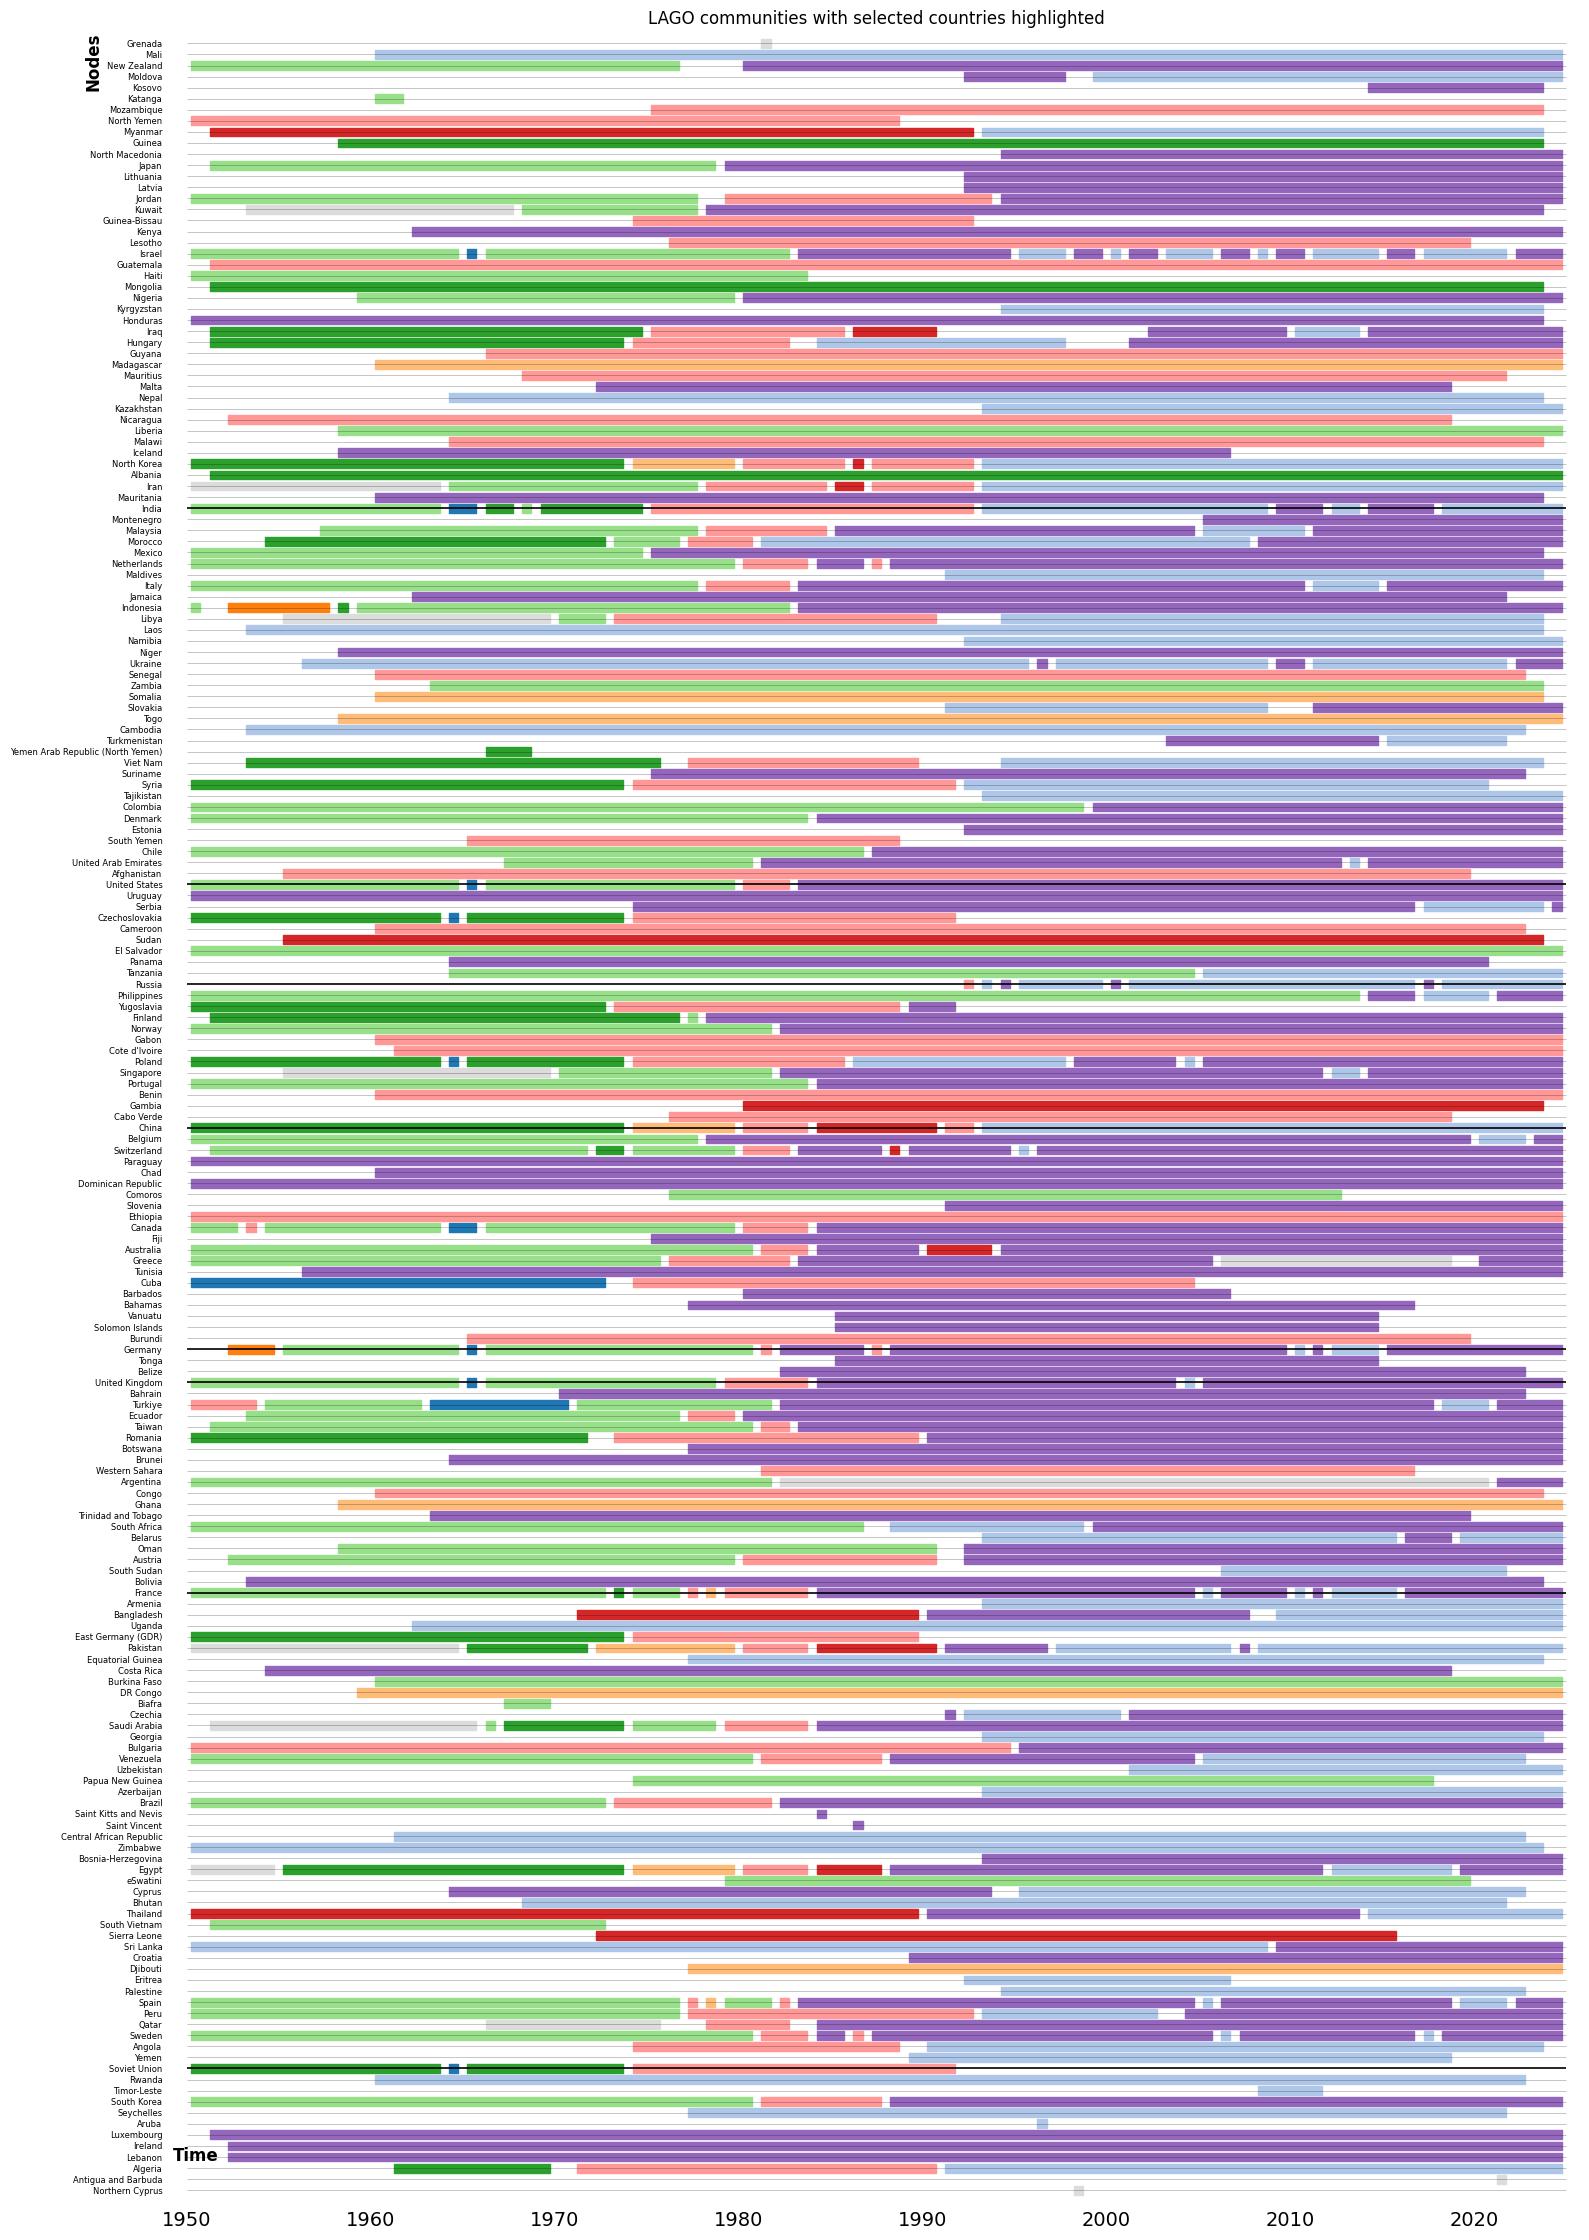

In [20]:
focus_ids = [
    node_to_id[country]
    for country in COUNTRIES_TO_TRACK
    if country in node_to_id
]

if focus_ids:
    # Keep every linkstream node in the plotting layout so edge endpoints remain
    # valid, but label and emphasize only the focal countries.
    all_node_ids = sorted(id_to_node)
    focal_labels = {
        node_id: id_to_node[node_id] if node_id in focus_ids else ""
        for node_id in all_node_ids
    }

    plot = LongitudinalModulesPlot(
        best_modules,
        linkstream=stream,
        width=1600,
        height=3000,
    )

    plot.configure_nodes(
        nodes=all_node_ids,
        labels=id_to_node,
        focus=all_node_ids,
        show_labels=True,
        auto_ordering=True,
        fontsize=6,
        linewidth=0.4,
        linewidth_focus=1.2,
    )

    plot.configure_edges(
        show_edges=False,
        show_activity=False,
    )

    plot.configure_modules(
        max_shown=min(20, best_modules.nb_modules),
        color_palette="tab20",
        height=0.8,
        focus_nodes=focus_ids,
    )

    plot.configure_display(
        padding_bottom=0.5,
        padding_top=0.5,
        show_xlabel=True,
        show_ylabel=True,
        show_xticks=True,
        label_fontsize=12,
    )

    fig, ax = plot.draw(
        title="LAGO communities with selected countries highlighted",
        return_ax=True,
        show_plot=False,
    )

    tick_step = 5 if (stream.max_time - stream.min_time) <= 35 else 10
    tick_positions = list(range(int(stream.min_time), int(stream.max_time) + 1, tick_step))
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([first_year + position for position in tick_positions])
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "selected_country_community_trajectories.png", dpi=180)
    plt.show()
else:
    print("None of the selected focal countries are present; visualization skipped.")

## 14. Targeted sensitivity analysis

γ and ω are free parameters, and our baseline uses the package defaults, so we
vary one decision at a time — γ up and down, ω up and down, and JM in place of
MM — to see how much of the partition follows from the data rather than from
that choice. Each specification is fitted once, since we want the direction and
size of the effect rather than a precise value.

In [22]:
RUN_SENSITIVITY = True

SENSITIVITY_CONFIGS = [
    {"label": "lower_gamma", "lex": LEX, "gamma": 0.5, "omega": OMEGA},
    {"label": "higher_gamma", "lex": LEX, "gamma": 2.0, "omega": OMEGA},
    {"label": "lower_omega", "lex": LEX, "gamma": GAMMA, "omega": 0.5},
    {"label": "higher_omega", "lex": LEX, "gamma": GAMMA, "omega": 5.0},
    {"label": "joint_membership", "lex": "JM", "gamma": GAMMA, "omega": OMEGA},
]

sensitivity_rows = []
sensitivity_modules = {}

if RUN_SENSITIVITY:
    for config in SENSITIVITY_CONFIGS:
        print(f"\nRunning sensitivity specification: {config['label']}")
        result = run_lago_configuration(
            stream,
            lex=config["lex"],
            gamma=config["gamma"],
            omega=config["omega"],
            restarts=1,
            refinement=None,
            refinement_in=False,
            fast_exploration=True,
            stopping_criterion=1e-6,
            verbose=0,
            seed=SEED,
        )

        modules = result["best_modules"]
        metric = result["best_metric"]
        switches = sum(
            len(modules.get_node_switches(node_id))
            for node_id in node_to_id.values()
        )
        sensitivity_modules[config["label"]] = modules
        sensitivity_rows.append({
            "specification": config["label"],
            "lex": config["lex"],
            "gamma": config["gamma"],
            "omega": config["omega"],
            "l_modularity": result["best_score"],
            "topological_component": metric.modularity_without_penalty,
            "time_penalty": metric.time_penalty,
            "modules": modules.nb_modules,
            "country_switches": switches,
            "runtime_minutes": result["best_runtime_seconds"] / 60,
        })

    sensitivity_results = pd.DataFrame(sensitivity_rows)
    sensitivity_results.to_csv(OUTPUT_DIR / "targeted_sensitivity_results.csv", index=False)
    display(sensitivity_results)
else:
    print("Sensitivity analysis skipped. Set RUN_SENSITIVITY = True when ready.")


Running sensitivity specification: lower_gamma
Starting restart 1/1 (seed=20260901)...
Finished restart 1/1: L-Modularity=0.5584, modules=8, runtime=1.7 minutes

Running sensitivity specification: higher_gamma
Starting restart 1/1 (seed=20260901)...
Finished restart 1/1: L-Modularity=0.2724, modules=155, runtime=0.5 minutes

Running sensitivity specification: lower_omega
Starting restart 1/1 (seed=20260901)...
Finished restart 1/1: L-Modularity=0.4296, modules=71, runtime=1.1 minutes

Running sensitivity specification: higher_omega
Starting restart 1/1 (seed=20260901)...
Finished restart 1/1: L-Modularity=0.3346, modules=11, runtime=0.8 minutes

Running sensitivity specification: joint_membership
Starting restart 1/1 (seed=20260901)...
Finished restart 1/1: L-Modularity=0.3429, modules=232, runtime=0.7 minutes


,specification,lex,gamma,omega,l_modularity,topological_component,time_penalty,modules,country_switches,runtime_minutes
0,lower_gamma,MM,0.5,2.0,0.558354,0.558616,-0.000262,8,4,1.720123
1,higher_gamma,MM,2.0,2.0,0.272357,0.329157,-0.056800,155,867,0.535837
2,lower_omega,MM,1.0,0.5,0.429627,0.444531,-0.014904,71,910,1.111675
3,higher_omega,MM,1.0,5.0,0.334560,0.352740,-0.018180,11,111,0.827232
4,joint_membership,JM,1.0,2.0,0.342937,0.398296,-0.055359,232,845,0.689445


## 15. Stability and final refinement runs

These are separate decisions:

1. **Stability run:** repeat the unrefined baseline at least three times to calculate ARI.
2. **Final refined run:** after selecting a plausible specification -- STEM refinement.

In [24]:
RUN_BASELINE_STABILITY = True
RUN_FINAL_REFINED = False

if RUN_BASELINE_STABILITY:
    stability_result = run_lago_configuration(
        stream,
        lex=LEX,
        gamma=GAMMA,
        omega=OMEGA,
        restarts=3,
        refinement=None,
        refinement_in=False,
        fast_exploration=True,
        stopping_criterion=1e-6,
        verbose=0,
        seed=SEED,
    )
    stability_result["run_table"].to_csv(
        OUTPUT_DIR / "baseline_stability_restarts.csv", index=False
    )
    print("Mean pairwise ARI:", stability_result["stability_ari"])
    display(stability_result["run_table"])

if RUN_FINAL_REFINED:
    refined_result = run_lago_configuration(
        stream,
        lex=LEX,
        gamma=GAMMA,
        omega=OMEGA,
        restarts=1,
        refinement="STEM",
        refinement_in=True,
        fast_exploration=True,
        stopping_criterion=1e-8,
        verbose=1,
        seed=SEED,
    )
    refined_result["best_modules"].to_json(
        OUTPUT_DIR / "refined_communities.json", use_segments=True
    )
    refined_result["run_table"].to_csv(
        OUTPUT_DIR / "refined_run.csv", index=False
    )
    display(refined_result["run_table"])

if not RUN_BASELINE_STABILITY and not RUN_FINAL_REFINED:
    print("Optional stability and refined runs skipped.")

Starting restart 1/3 (seed=20260901)...
Finished restart 1/3: L-Modularity=0.3677, modules=19, runtime=0.8 minutes
Starting restart 2/3 (seed=20260902)...
Finished restart 2/3: L-Modularity=0.3837, modules=35, runtime=0.8 minutes
Starting restart 3/3 (seed=20260903)...
Finished restart 3/3: L-Modularity=0.3886, modules=20, runtime=0.8 minutes
Mean pairwise ARI: 0.27610274463140844


,restart,seed,l_modularity,topological_component,time_penalty,communities,runtime_seconds
0,1,20260901,0.367710,0.385136,-0.017427,19,50.165426
1,2,20260902,0.383669,0.407123,-0.023454,35,48.264196
2,3,20260903,0.388550,0.405912,-0.017361,20,49.324430
